In [9]:
import os
from PIL import Image
import numpy as np
orig_img_dir = './dataset/OSIC/val/images'

def get_img(img_base_dir, img_name):
    model_dirs = sorted(os.listdir(img_base_dir))
    imgs = {}
    for img_dir in model_dirs:
        img_path = os.path.join(img_base_dir, img_dir, img_name)
        img = Image.open(img_path)
        imgs[img_dir.split('_')[-1]] = np.array(img)
    print(imgs.keys())
    return imgs

# show the images
'''
As the training steps progress, the fake A2B1 images become more realistic (no color) and less A-liked (fibrosis features are less visible).
'''
import matplotlib.pyplot as plt
def show_images(imgs):
    fig, axes = plt.subplots(len(imgs)//5, 5, figsize=(15, 3*(len(imgs)//5)))
    axes = axes.flatten()
    for ax, (name, img) in zip(axes, imgs.items()):
        ax.imshow(img)
        ax.set_title(name)
        ax.axis('off')
    plt.tight_layout()

dict_keys(['0006600.pt', '0006700.pt', '0006800.pt', '0006900.pt', '0007000.pt', '0008000.pt', '0009000.pt', '0010000.pt', '0011000.pt', '0012000.pt', '0012800.pt', '0012900.pt', '0013000.pt', '0013100.pt', '0013200.pt', '0022000.pt', '0023000.pt', '0024000.pt', '0025000.pt', '0026000.pt'])


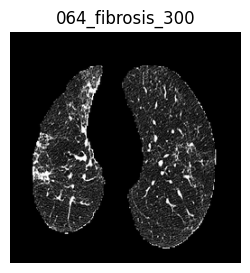

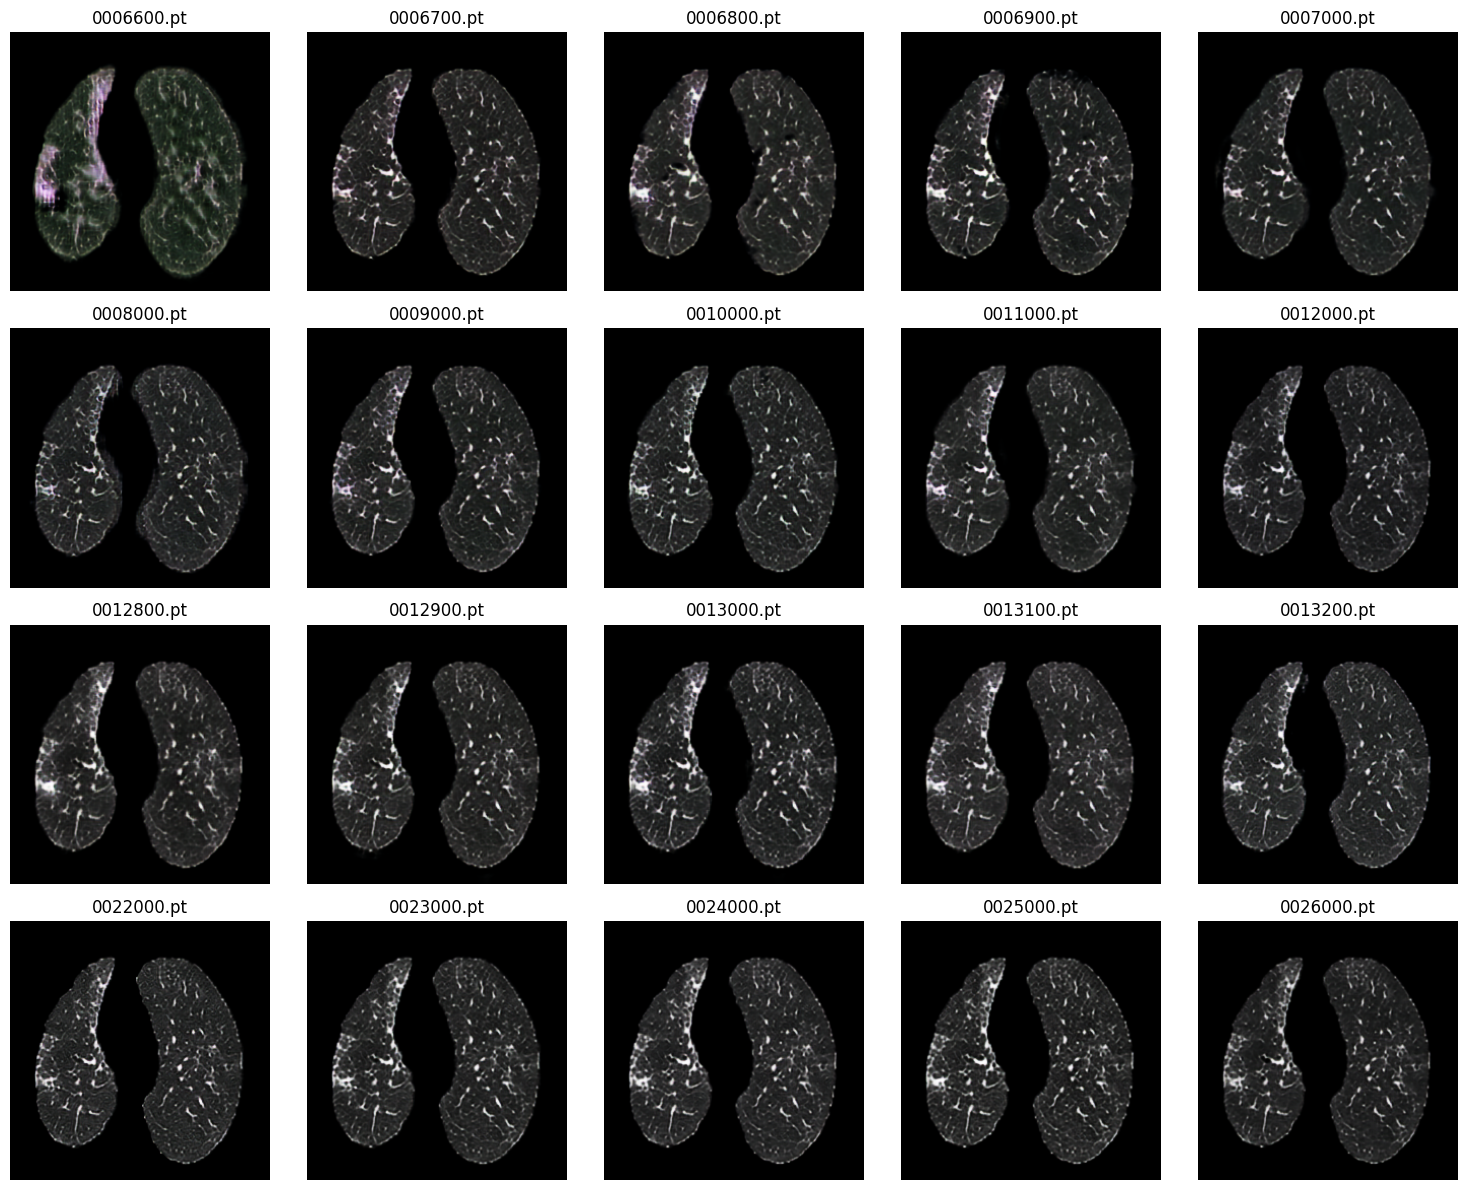

In [10]:
img_base_dir = './results/OSIC/val_folder/fake_A2B1'
img_name = '064_fibrosis_300.png'
imgs = get_img(img_base_dir, img_name)
orig_img = Image.open(os.path.join(orig_img_dir, img_name))
plt.figure(figsize=(3, 3))
plt.imshow(orig_img)
plt.axis('off')
plt.title(img_name.split('.')[0])

show_images(imgs)

dict_keys(['0006600.pt', '0006700.pt', '0006800.pt', '0006900.pt', '0007000.pt', '0008000.pt', '0009000.pt', '0010000.pt', '0011000.pt', '0012000.pt', '0012800.pt', '0012900.pt', '0013000.pt', '0013100.pt', '0013200.pt', '0022000.pt', '0023000.pt', '0024000.pt', '0025000.pt', '0026000.pt'])


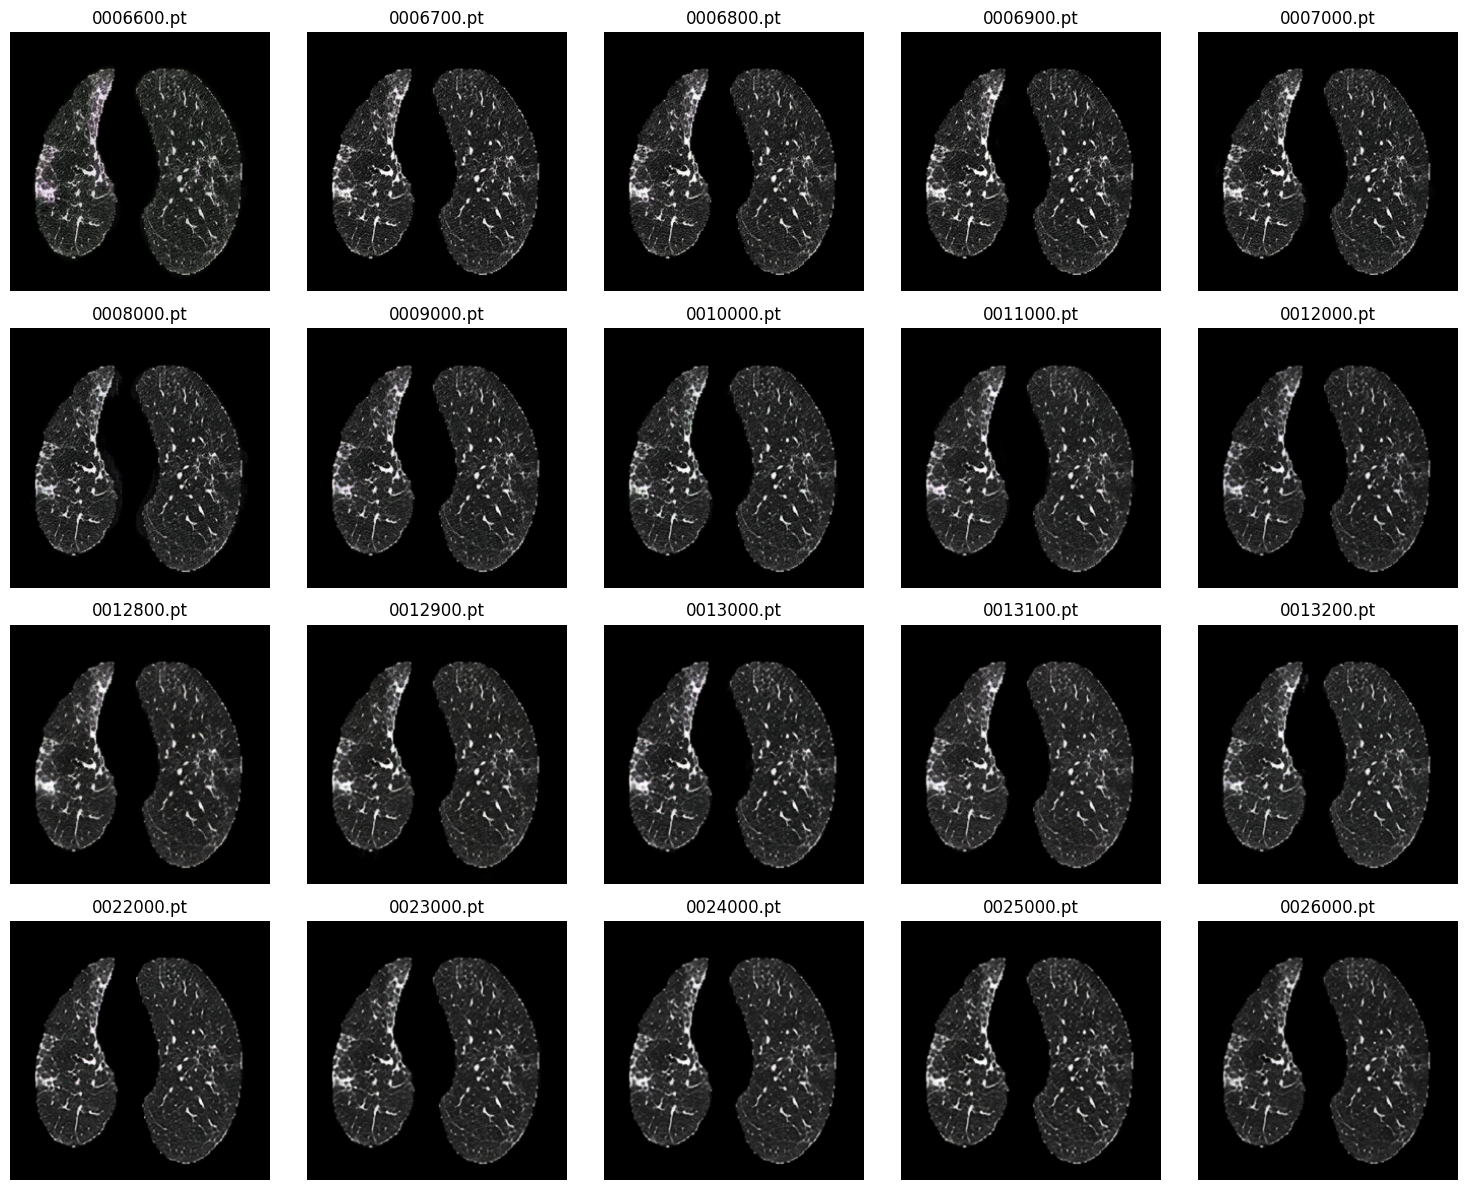

In [11]:
img_base_dir = './results/OSIC/val_folder/fake_A2B_21'
img_name = '064_fibrosis_300.png'
imgs = get_img(img_base_dir, img_name)
show_images(imgs)

dict_keys(['0006600.pt', '0006700.pt', '0006800.pt', '0006900.pt', '0007000.pt', '0008000.pt', '0009000.pt', '0010000.pt', '0011000.pt', '0012000.pt', '0012800.pt', '0012900.pt', '0013000.pt', '0013100.pt', '0013200.pt', '0022000.pt', '0023000.pt', '0024000.pt', '0025000.pt', '0026000.pt'])


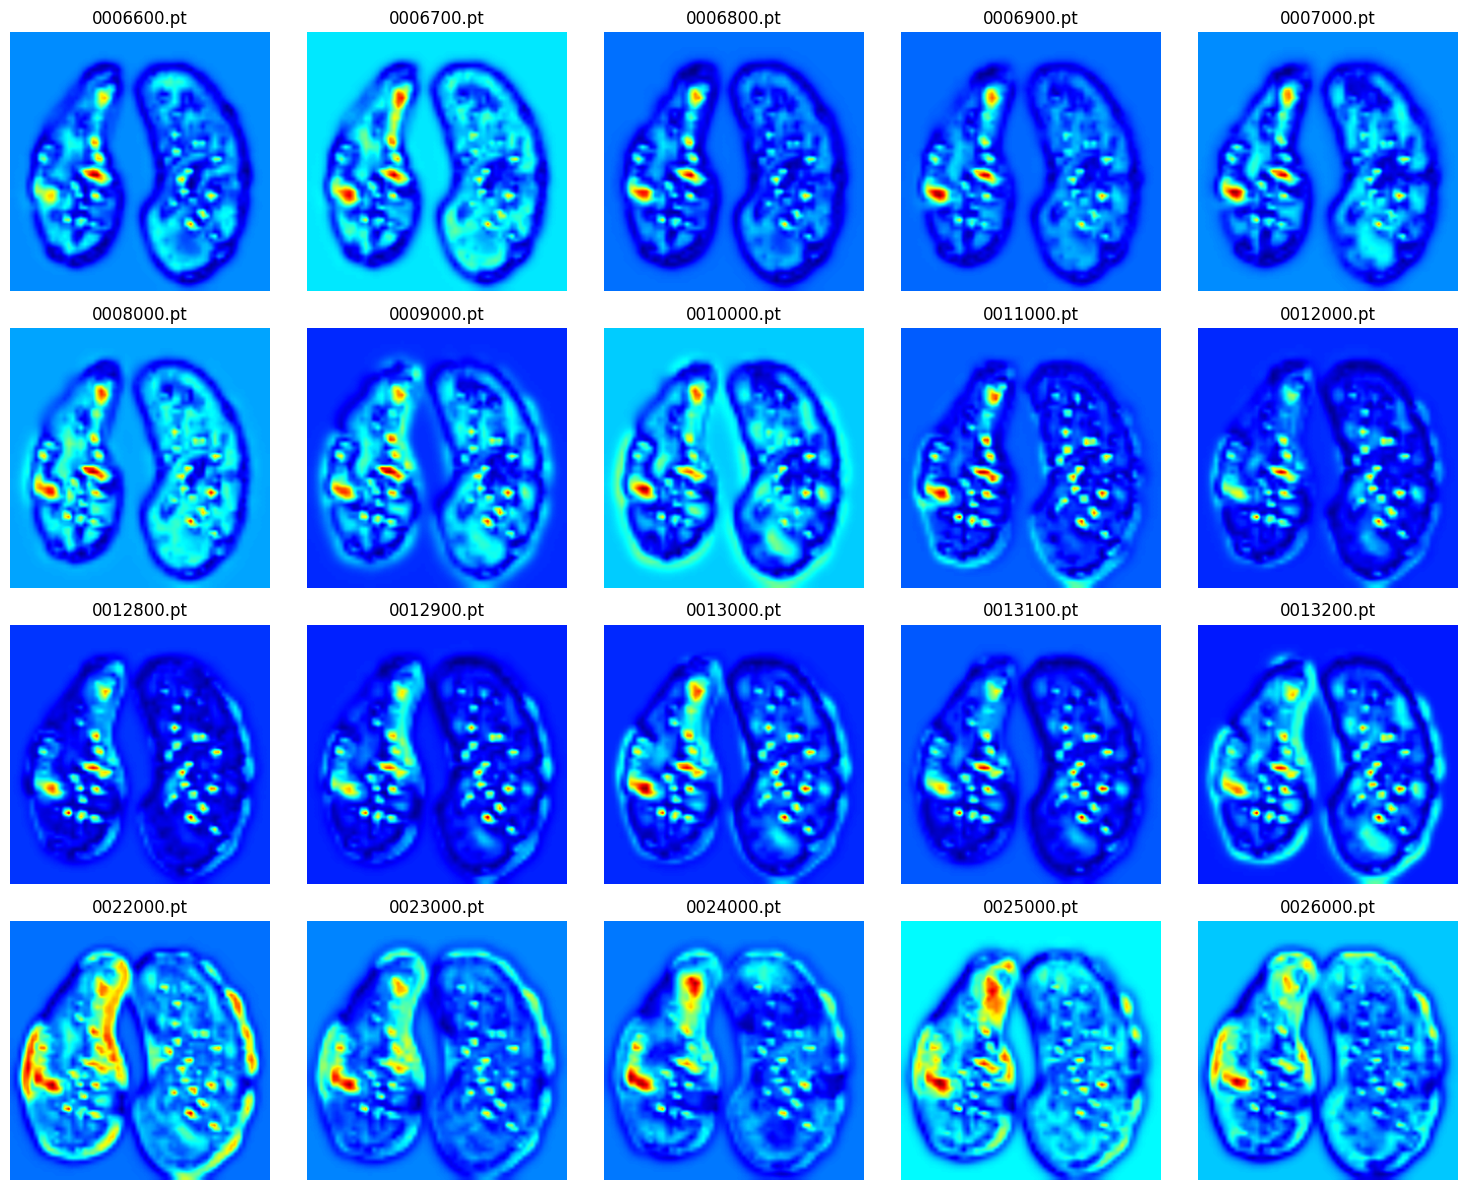

In [12]:
img_base_dir = './results/OSIC/val_folder/heatmap_A2B1'
img_name = '064_fibrosis_300.png'
imgs = get_img(img_base_dir, img_name)
show_images(imgs)

dict_keys(['0006600.pt', '0006700.pt', '0006800.pt', '0006900.pt', '0007000.pt', '0008000.pt', '0009000.pt', '0010000.pt', '0011000.pt', '0012000.pt', '0012800.pt', '0012900.pt', '0013000.pt', '0013100.pt', '0013200.pt', '0022000.pt', '0023000.pt', '0024000.pt', '0025000.pt', '0026000.pt'])


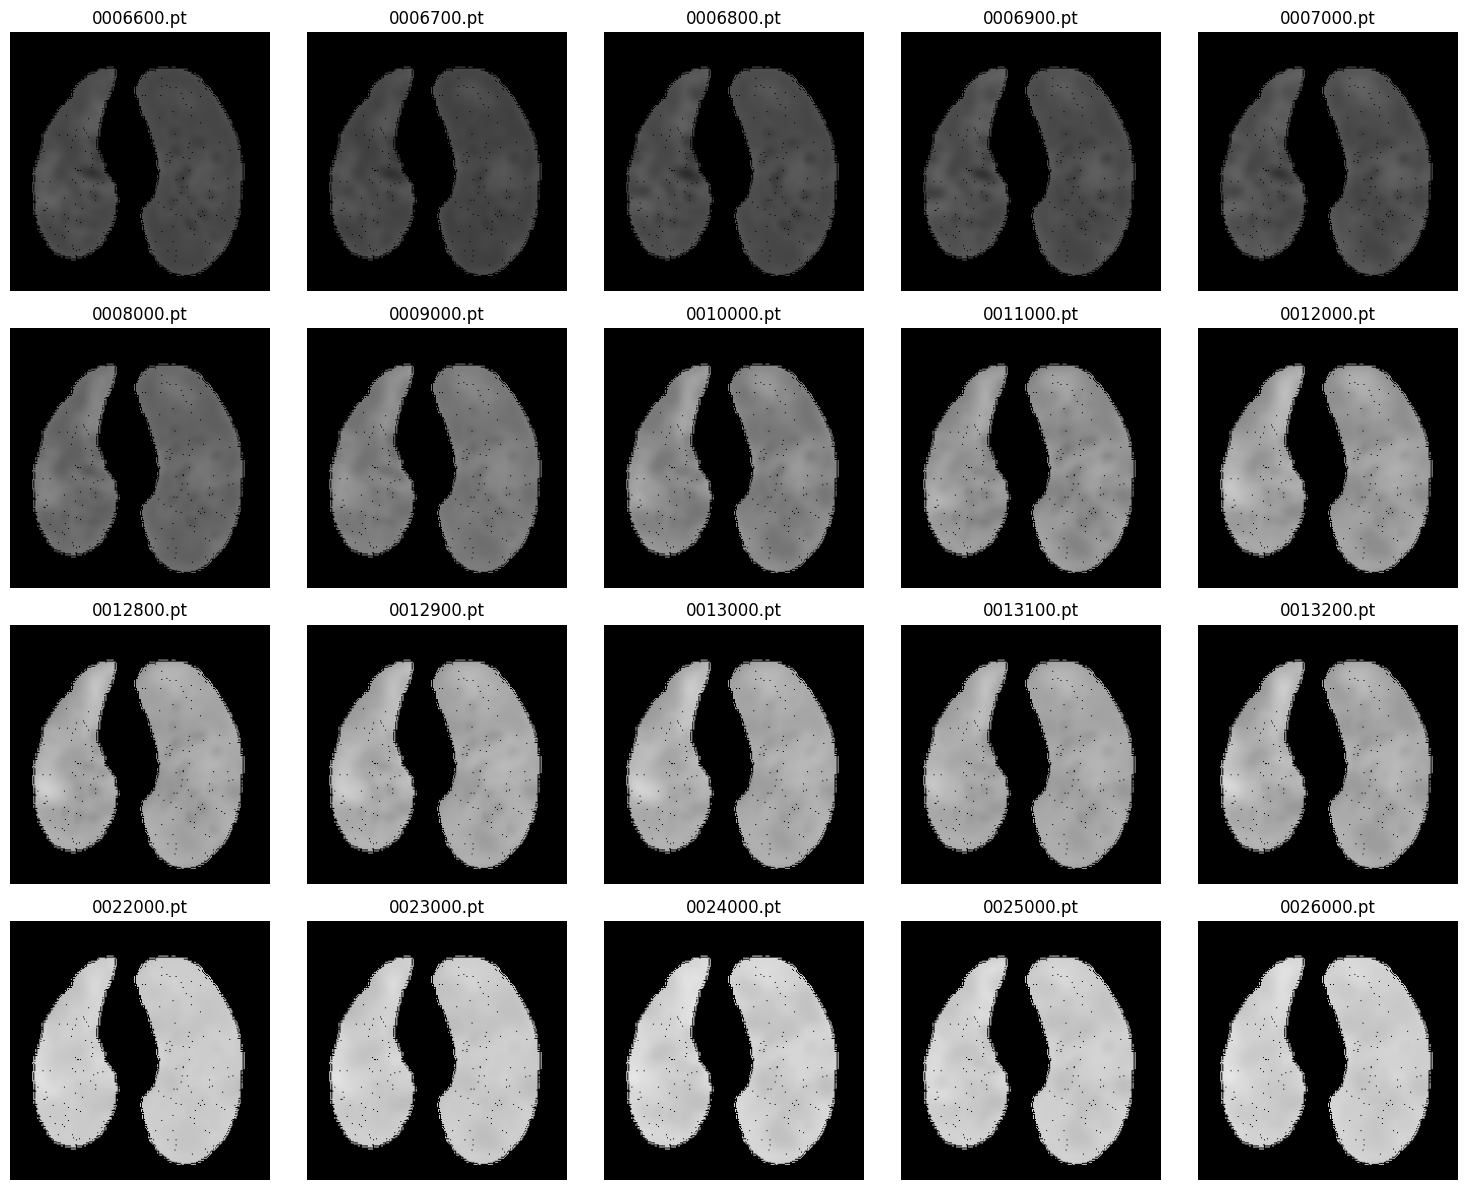

In [18]:
img_base_dir = './results/OSIC/val_folder/results_mask1'
img_name = '064_fibrosis_300.png'
imgs = get_img(img_base_dir, img_name)
show_images(imgs)

In [1]:
# infer process
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '1'
from CBFNet import CBFNet
import yaml
config_path = "./configs/OSIC_default.yaml"
# Load the YAML file
with open(config_path, 'r') as file:
    args = yaml.unsafe_load(file)
args.exp_name = 'less_equal_trainA'
print(args)  # Output: Namespace(phase='train', batch_size=32)
# debug orig pre-trained model
# args.dataset = 'BraTS'
# args.folder = 'brats_1'

# open session
gan = CBFNet(args)
gan.build_model()

Namespace(adv_weight=1, batch_size=1, benchmark_flag=False, cam_weight=1000, ch=54, cycle_weight=10, dataset='OSIC', decay_flag=False, device='cuda', exp_name='less_equal_trainA', folder='', identity_weight=10, img_ch=3, img_size=256, iteration=7000, light=True, lr=0.0001, n_dis=6, n_res=4, phase='val', print_freq=50, recon_weight=10, result_dir='results', resume=False, save_freq=50, stage=1, weight_decay=2e-05)

##### Information #####
# light :  True
# dataset :  OSIC
# batch_size :  1
# iteration per epoch :  7000

##### Generator #####
# residual blocks :  4

##### Discriminator #####
# discriminator layer :  6

##### Weight #####
# adv_weight :  1
# cycle_weight :  10
# identity_weight :  10
# cam_weight :  1000


In [2]:
from networks import *
from utils import *
from glob import glob
import os
import matplotlib.pyplot as plt
def infer(self):
    list_model = sorted(
        glob(os.path.join(self.result_dir, self.dataset, self.folder, self.exp_name, '*' + '000.pt'))) # get the model list each 1000.
    if len(list_model) == 0:
        list_model = sorted(glob(os.path.join(self.result_dir, self.dataset, self.folder, self.exp_name, '*' + '.pt')))
    max_value = [0, 0, 0, 0, 0]
    
    for m in list_model[-1:]:
        model_list = glob(
                os.path.join(self.result_dir, self.dataset, self.folder, self.exp_name,
                                str(m.split('/')[-1].split('\'')[0])))
        if not len(model_list) == 0:
            model_list.sort()
            iter = int(model_list[-1].split('_')[-1].split('.')[0])
            # iter = int('0007000')
            iter = int('0006000')
            self.load(os.path.join(self.result_dir, self.dataset, self.folder, self.exp_name), iter)
            
            # # load pre-trained BraTS model
            # BraTS_model_path = "/media/NAS06/gavinyue/genai-wsss/benchmarks/MedImgSeg/results/BraTS/brats_1/model1/BraTS_params_0005250.pt"
            # params = torch.load(BraTS_model_path)
            # self.genA2B.load_state_dict(params['genA2B'])
            # self.genB2A.load_state_dict(params['genB2A'])
            # self.disGA.load_state_dict(params['disGA'])
            # self.disGB.load_state_dict(params['disGB'])
            # self.disLA.load_state_dict(params['disLA'])
            # self.disLB.load_state_dict(params['disLB'])
            
            print(" [*] Load SUCCESS")
            pass
        else:
            print(" [*] Load FAILURE")
            return

    self.genA2B.eval()
    for n, (real_A, _, pathA) in enumerate(self.valA_loader):
        if '064_fibrosis_300.png' in pathA[0]:
            real_A = real_A.to(self.device)
            real_A2 = real_A

            fake_A2B, cam_logit, fake_A2B_heatmap, att_maskA2B, fake_A2B_2, real_A2_r = self.genA2B(real_A2)
            return fake_A2B, cam_logit, fake_A2B_heatmap, att_maskA2B, fake_A2B_2, real_A2_r, real_A2, pathA
        else:
            continue
# shape [1, 3, 256, 256], cam_logit.shape=[1,2], fake_A2B_heatmap.shape=[1,1,64,64]

In [3]:
from utils import denorm, tensor2numpy, RGB2BGR
import cv2
def cam(x, size = 256):
    x = x - np.min(x) # Normalize x to start from 0
    cam_img = x / np.max(x) # Normalize x to the range [0, 1]
    cam_img = np.uint8(255 * cam_img)
    cam_img = cv2.resize(cam_img, (size, size))
    # cam_img = cv2.applyColorMap(cam_img, cv2.COLORMAP_JET) # Apply a heatmap color map
    return cam_img / 255.0 # Normalize the heatmap to [0, 1]

fake_A2B, cam_logit, fake_A2B_heatmap, att_maskA2B, fake_A2B_2, real_A2_r, real_A2, pathA = infer(gan)

imgs = {'real_A2': real_A2, 'real_A2_r': real_A2_r, 'fake_A2B': fake_A2B, 'fake_A2B_2': fake_A2B_2}
for keys,img in imgs.items():
    imgs[keys] = RGB2BGR(tensor2numpy(denorm(img[0])))
    
att_maskA2B = RGB2BGR(tensor2numpy(denorm(att_maskA2B[0])) * 2 - 1)
fake_A2B_heatmap = cam(tensor2numpy(fake_A2B_heatmap[0]), gan.img_size)


print(f"att_maskA2B range {att_maskA2B.min()} - {att_maskA2B.max()}")
print(f"fake_A2B_heatmap range {fake_A2B_heatmap.min()} - {fake_A2B_heatmap.max()}")
print(f"fake_A2B_heatmap shape {fake_A2B_heatmap.shape}")

 [*] Load SUCCESS
att_maskA2B range 0.12238025665283203 - 0.25872159004211426
fake_A2B_heatmap range 0.01568627450980392 - 0.9450980392156862
fake_A2B_heatmap shape (256, 256)


In [48]:
from utils import denorm, tensor2numpy, RGB2BGR
import cv2
def cam(x, size = 256):
    x = x - np.min(x) # Normalize x to start from 0
    cam_img = x / np.max(x) # Normalize x to the range [0, 1]
    cam_img = np.uint8(255 * cam_img)
    cam_img = cv2.resize(cam_img, (size, size))
    # cam_img = cv2.applyColorMap(cam_img, cv2.COLORMAP_JET) # Apply a heatmap color map
    return cam_img / 255.0 # Normalize the heatmap to [0, 1]

fake_A2B, cam_logit, fake_A2B_heatmap, att_maskA2B, fake_A2B_2, real_A2_r, real_A2, pathA = infer(gan)

imgs = {'real_A2': real_A2, 'real_A2_r': real_A2_r, 'fake_A2B': fake_A2B, 'fake_A2B_2': fake_A2B_2}
for keys,img in imgs.items():
    imgs[keys] = RGB2BGR(tensor2numpy(denorm(img[0])))
    
att_maskA2B = RGB2BGR(tensor2numpy(denorm(att_maskA2B[0])) * 2 - 1)
fake_A2B_heatmap = cam(tensor2numpy(fake_A2B_heatmap[0]), gan.img_size)


print(f"att_maskA2B range {att_maskA2B.min()} - {att_maskA2B.max()}")
print(f"fake_A2B_heatmap range {fake_A2B_heatmap.min()} - {fake_A2B_heatmap.max()}")
print(f"fake_A2B_heatmap shape {fake_A2B_heatmap.shape}")

 [*] Load SUCCESS
att_maskA2B range 0.0 - 0.9476318359375
fake_A2B_heatmap range 0.0 - 0.9725490196078431
fake_A2B_heatmap shape (256, 256)


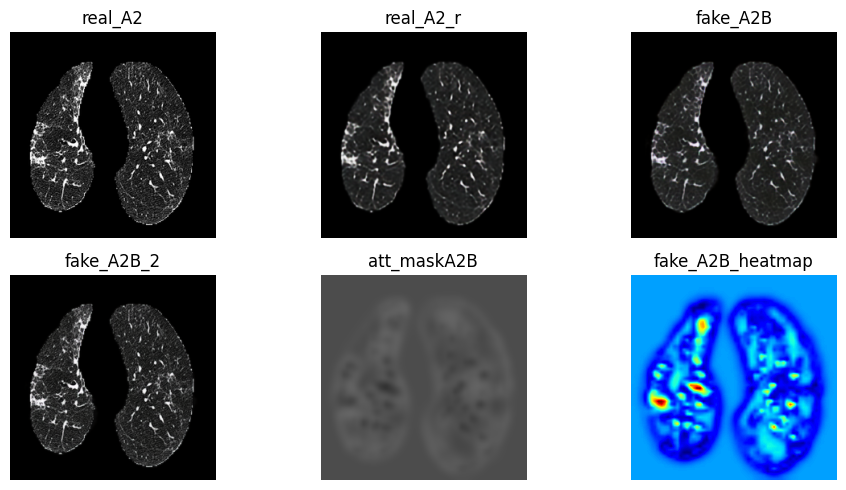

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(10, 5))
ax = axes.flatten()
for i, (name, img) in enumerate(imgs.items()):
    ax[i].imshow(img)
    ax[i].set_title(name)
    ax[i].axis('off')
ax[4].imshow(att_maskA2B)
ax[4].set_title('att_maskA2B')
ax[4].axis('off')
ax[5].imshow(fake_A2B_heatmap, cmap = 'jet')
ax[5].set_title('fake_A2B_heatmap')
ax[5].axis('off')
plt.tight_layout()

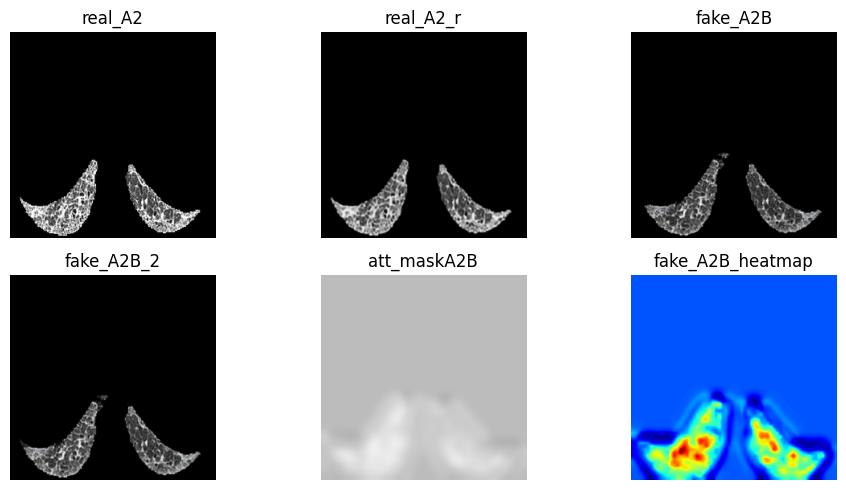

In [31]:
fig, axes = plt.subplots(2, 3, figsize=(10, 5))
ax = axes.flatten()
for i, (name, img) in enumerate(imgs.items()):
    ax[i].imshow(img)
    ax[i].set_title(name)
    ax[i].axis('off')
ax[4].imshow(att_maskA2B)
ax[4].set_title('att_maskA2B')
ax[4].axis('off')
ax[5].imshow(fake_A2B_heatmap, cmap = 'jet')
ax[5].set_title('fake_A2B_heatmap')
ax[5].axis('off')
plt.tight_layout()

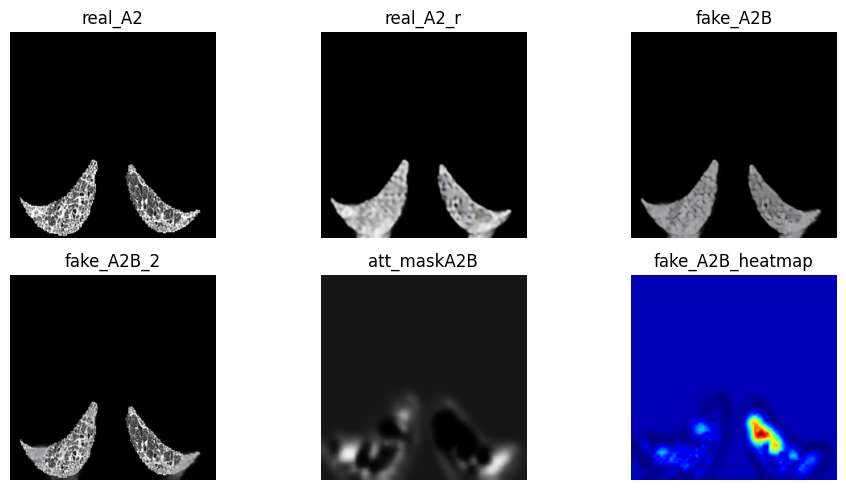

In [49]:
fig, axes = plt.subplots(2, 3, figsize=(10, 5))
ax = axes.flatten()
for i, (name, img) in enumerate(imgs.items()):
    ax[i].imshow(img)
    ax[i].set_title(name)
    ax[i].axis('off')
ax[4].imshow(att_maskA2B)
ax[4].set_title('att_maskA2B')
ax[4].axis('off')
ax[5].imshow(fake_A2B_heatmap, cmap = 'jet')
ax[5].set_title('fake_A2B_heatmap')
ax[5].axis('off')
plt.tight_layout()

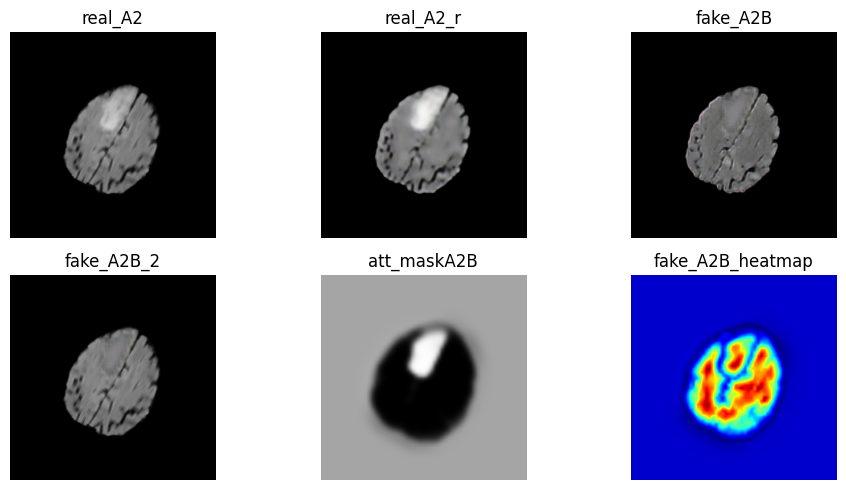

In [35]:
fig, axes = plt.subplots(2, 3, figsize=(10, 5))
ax = axes.flatten()
for i, (name, img) in enumerate(imgs.items()):
    ax[i].imshow(img)
    ax[i].set_title(name)
    ax[i].axis('off')
ax[4].imshow(att_maskA2B)
ax[4].set_title('att_maskA2B')
ax[4].axis('off')
ax[5].imshow(fake_A2B_heatmap, cmap = 'jet')
ax[5].set_title('fake_A2B_heatmap')
ax[5].axis('off')
plt.tight_layout()

(256, 256, 3) uint8 0 255
unique values: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108
 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126
 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144
 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162
 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180
 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198
 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215 216
 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233 234
 235 236 2

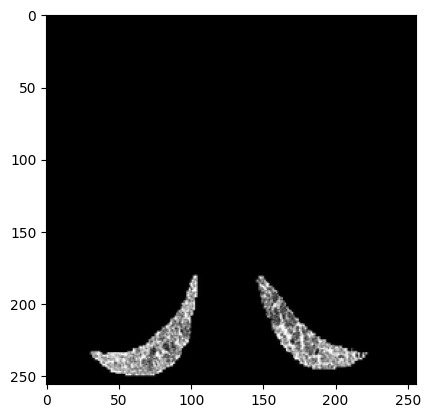

In [11]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
mask_path = '/media/NAS06/gavinyue/genai-wsss/benchmarks/MedImgSeg/dataset/BraTS/brats_1/563_A_weak/Brats18_2013_9_1_flair.nii_100.png'
mask_path = '/media/NAS06/gavinyue/genai-wsss/benchmarks/MedImgSeg/dataset/OSIC/fibrosis/033_fibrosis_027.png'
mask = Image.open(mask_path)
mask = np.array(mask)
print(mask.shape, mask.dtype, mask.min(), mask.max())
print(f"unique values: {np.unique(mask)}")

plt.imshow(mask, cmap='jet')

In [13]:
new_heatmap = np.uint8(fake_A2B_heatmap*255)
print(new_heatmap.shape, new_heatmap.dtype, new_heatmap.min(), new_heatmap.max())
print(f"unique values: {np.unique(new_heatmap)}")

diff = np.abs(mask - new_heatmap)
print(diff.shape, diff.dtype, diff.min(), diff.max())
np.array_equal(mask, new_heatmap)

(256, 256, 3) uint8 0 255
unique values: [  0   1   2   4   6   8  10  12  14  16  18  20  22  24  26  28  30  32
  34  36  38  40  42  44  46  48  50  52  54  56  58  60  62  64  66  68
  70  72  74  76  78  80  82  84  86  88  90  92  94  96  98 100 102 104
 106 108 110 112 114 116 118 120 122 124 126 128 130 132 134 136 138 140
 142 144 146 148 150 152 154 156 158 160 162 164 166 168 170 172 174 176
 178 180 182 184 186 188 190 192 194 196 198 200 202 204 206 208 210 212
 214 216 218 220 222 224 226 228 230 232 234 236 238 240 242 244 246 248
 250 252 254 255]
(256, 256, 3) uint8 0 255


False

In [5]:
from findContours import findCont
from five_metrics import five_m
def val(self):
    list_model = sorted(
        glob(os.path.join(self.result_dir, self.dataset, self.folder, 'model' + str(self.stage), '*' + '000.pt'))) # get the model list each 1000.
    if len(list_model) == 0:
        list_model = sorted(glob(os.path.join(self.result_dir, self.dataset, self.folder, 'model' + str(self.stage), '*' + '.pt')))
    max_value = [0, 0, 0, 0, 0]
    start_model = '008000'
    for i, m in enumerate(list_model):
        if start_model in m:
            list_model = list_model[i: i+5]
            break
    assert len(list_model) > 0 and len(list_model) <= 5
    for m in list_model[-5:]:
        model_list = glob(
            os.path.join(self.result_dir, self.dataset, self.folder, 'model' + str(self.stage),
                            str(m.split('/')[-1].split('\'')[0])))
        model_name = str(m.split('/')[-1].split('\'')[0])
        if not len(model_list) == 0:
            model_list.sort()
            iter = int(model_list[-1].split('_')[-1].split('.')[0])
            self.load(os.path.join(self.result_dir, self.dataset, self.folder, 'model' + str(self.stage)), iter)
            print(" [*] Load SUCCESS")
        else:
            print(" [*] Load FAILURE")
            return

        self.genA2B.eval(), self.genB2A.eval()
        for n, (real_A, _, pathA) in enumerate(self.valA_loader):
            real_A = real_A.to(self.device)
            real_A2 = real_A

            fake_A2B, cam_logit, fake_A2B_heatmap, att_maskA2B, fake_A2B_2, real_A2_r = self.genA2B(real_A2)

            pathA = pathA[0].split('/')[-1].split('.')[0] + '.' + pathA[0].split('/')[-1].split('.')[1]


            path1 = os.path.join(self.result_dir, self.dataset, self.folder, 'val_folder',
                                    'results_mask_reverse' + str(self.stage), model_name)
            path2 = os.path.join(self.result_dir, self.dataset, self.folder, 'val_folder',
                                    'iccv_labels' + str(self.stage), model_name)
            path3 = os.path.join(self.result_dir, self.dataset, self.folder, 'val_folder',
                                    'results_mask' + str(self.stage), model_name)
            path4 = os.path.join(self.result_dir, self.dataset, self.folder, 'val_folder',
                                    'heatmap_A2B' + str(self.stage), model_name)
            path5 = os.path.join(self.result_dir, self.dataset, self.folder, 'val_folder',
                                    'fake_A2B' + str(self.stage), model_name)
            path6 = os.path.join(self.result_dir, self.dataset, self.folder, 'val_folder',
                                    'fake_A2B_2' + str(self.stage), model_name)

            if (os.path.exists(path1) != True):
                os.makedirs(path1)
            if (os.path.exists(path2) != True):
                os.makedirs(path2)
            if (os.path.exists(path3) != True):
                os.makedirs(path3)
            if (os.path.exists(path4) != True):
                os.makedirs(path4)
            if (os.path.exists(path5) != True):
                os.makedirs(path5)
            if (os.path.exists(path6) != True):
                os.makedirs(path6)

            background = torch.zeros_like(att_maskA2B).to(self.device)
            att_maskA2B = torch.where(real_A2 > -1, att_maskA2B, background)

            att_maskA2B_r = 1 - att_maskA2B
            MASKA2B_r = RGB2BGR(tensor2numpy(denorm(att_maskA2B_r[0])) * 2 - 1)
            if (self.dataset == "ISIC"):
                pathA = pathA.split('.')[0]
            elif (self.dataset == "OSIC"):
                pathA = pathA.split('.')[0] #remove '.png'
            cv2.imwrite(os.path.join(path1, pathA + '_a2_b.png'), MASKA2B_r * 255.0)

            att_maskA2B = att_maskA2B
            MASKA2B = RGB2BGR(tensor2numpy(denorm(att_maskA2B[0])) * 2 - 1)
            cv2.imwrite(os.path.join(path3, pathA + '.png'), MASKA2B * 255.0)

            HEATMAP_A2B = cam(tensor2numpy(fake_A2B_heatmap[0]), self.img_size)
            cv2.imwrite(os.path.join(path4, pathA + '.png'), HEATMAP_A2B * 255.0)

            FAKEA2B = RGB2BGR(tensor2numpy(denorm(fake_A2B[0])))
            cv2.imwrite(os.path.join(path5, pathA + '.png'), FAKEA2B * 255.0)

            FAKEA2B_2 = RGB2BGR(tensor2numpy(denorm(fake_A2B_2[0])))
            cv2.imwrite(os.path.join(path6, pathA + '.png'), FAKEA2B_2 * 255.0)

        root_path = os.path.join(self.result_dir, self.dataset, self.folder)
        find_path = os.path.join(path1)
        find_output_path = os.path.join(path2)
        findCont(model_name, find_path, find_output_path)
        five_pre_path = os.path.join(path2)
        five_label_path = os.path.join('dataset', self.dataset, self.folder, 'val', 'labels')
        return_value = five_m(model_name, five_pre_path, five_label_path, self.dataset, self.folder, self.stage)
        if (return_value[0] > max_value[0]):
            max_value = return_value.copy()
            with open(root_path + "/val_max.txt", "w") as f:
                f.write(self.dataset)
                f.write('\n')
                f.write(self.folder)
                f.write('\n')
                f.write(", ".join(str(i) for i in max_value))
                f.write('\n')
                f.write(model_name)
                f.write('\n')
        print(" max_value: %s " % max_value)
        print(" %s Val finished!" % (model_name))

    print(" All Val finished!")
    
val(gan)

 [*] Load SUCCESS
8.33 %
16.67 %
25.0 %
33.33 %
41.67 %
50.0 %
58.33 %
66.67 %
75.0 %
83.33 %
91.67 %
100.0 %
JA:0.3801 
AC:0.7451 
DI:0.4848 
SE:0.8024 
SP:0.7357 
  JA     AC     DI      SE     SP
0.3801, 0.7451, 0.4848, 0.8024, 0.7357
 max_value: [0.3801 0.7451 0.4848 0.8024 0.7357] 
 OSIC_params_0008000.pt Val finished!


 [*] Load SUCCESS
8.33 %
16.67 %
25.0 %
33.33 %
41.67 %
50.0 %
58.33 %
66.67 %
75.0 %
83.33 %
91.67 %
100.0 %
JA:0.3661 
AC:0.7389 
DI:0.4736 
SE:0.7800 
SP:0.7364 
  JA     AC     DI      SE     SP
0.3661, 0.7389, 0.4736, 0.78, 0.7364
 max_value: [0.3801 0.7451 0.4848 0.8024 0.7357] 
 OSIC_params_0009000.pt Val finished!
 [*] Load SUCCESS
8.33 %
16.67 %
25.0 %
33.33 %
41.67 %
50.0 %
58.33 %
66.67 %
75.0 %
83.33 %
91.67 %
100.0 %
JA:0.3622 
AC:0.7378 
DI:0.4702 
SE:0.7781 
SP:0.7371 
  JA     AC     DI      SE     SP
0.3622, 0.7378, 0.4702, 0.7781, 0.7371
 max_value: [0.3801 0.7451 0.4848 0.8024 0.7357] 
 OSIC_params_0010000.pt Val finished!
 [*] Load SUCCESS
8.33 %
16.67 %
25.0 %
33.33 %
41.67 %
50.0 %
58.33 %
66.67 %
75.0 %
83.33 %
91.67 %
100.0 %
JA:0.3680 
AC:0.7412 
DI:0.4752 
SE:0.7762 
SP:0.7420 
  JA     AC     DI      SE     SP
0.368, 0.7412, 0.4752, 0.7762, 0.742
 max_value: [0.3801 0.7451 0.4848 0.8024 0.7357] 
 OSIC_params_0011000.pt Val finished!
 [*] Load SUCCESS
8.33 %
1